# Assignment 1 2AMM10 2025-2026

## Group: [Name Editing]
### Member 1: [Chang Qin]
### Member 2: [Fill in your name]
### Member 3: [Fill in your name]

In [5]:
import torch
import json
import torch.nn as nn
import pandas as pd
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import random
import numpy as np

## Global Variables ##
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
DATA_DIR = "./data"
DROWSY_DATASET_DIR = Path(
    DATA_DIR, "drowsy_graph_dataset"
)  # Path to the drowsy dataset
OBJ_CLS_DATASET_DIR = Path(
    DATA_DIR, "bdd8cls_balanced_300_30"
)  # Path to the object classification dataset
DEVICE = (
    torch.device("cuda")
    if torch.cuda.is_available()
    else (
        torch.device("mps")
        if torch.backends.mps.is_available()
        else torch.device("cpu")
    )
)

# Task 1

In [1]:
class DrowsyFaceGraphDataset(Dataset):
    def __init__(self, root, split="train"):
        self.root = Path(root)
        self.split = split

        data_path = self.root / f"{split}.pt"
        class_to_id_path = self.root / "class_to_id.json"
        id_to_class_path = self.root / "id_to_class.json"

        if not data_path.exists():
            raise FileNotFoundError(f"Could not find {data_path}")

        self.graphs = torch.load(data_path, weights_only=False)

        with open(class_to_id_path, "r") as f:
            self.class_to_id = json.load(f)

        with open(id_to_class_path, "r") as f:
            self.id_to_class = json.load(f)

    def __len__(self):
        return len(self.graphs)

    def __getitem__(self, idx):
        return self.graphs[idx]


train_dataset = DrowsyFaceGraphDataset(root=DROWSY_DATASET_DIR, split="train")
test_dataset = DrowsyFaceGraphDataset(root=DROWSY_DATASET_DIR, split="test")
class_to_id: dict = train_dataset.class_to_id
id_to_class: dict = train_dataset.id_to_class

##

In [2]:
# Visualization helper
def plot_face_graph(
    graph, ax=None, title=None, node_size=8, edge_alpha=0.20, edge_width=0.4
):
    """Plot one face graph using its 2D normalized landmark coordinates."""
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))

    coords = graph.x.cpu().numpy()  # Nodes of the Graph
    edge_index = graph.edge_index.cpu().numpy()  # Edges of the Graph

    xy = coords[:, :2]

    seen = set()
    for i, j in edge_index.T:
        a, b = int(i), int(j)
        key = tuple(sorted((a, b)))
        if key in seen:
            continue
        seen.add(key)
        ax.plot(
            [xy[a, 0], xy[b, 0]],
            [xy[a, 1], xy[b, 1]],
            linewidth=edge_width,
            alpha=edge_alpha,
        )

    ax.scatter(xy[:, 0], xy[:, 1], s=node_size)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.axis("off")

    if title is not None:
        ax.set_title(title)

    return ax


fig, ax = plt.subplots()
idx = random.randint(0, len(train_dataset) - 1)
graph = train_dataset[idx]
x, y = graph.x, graph.y
plot_face_graph(graph, ax)


# Understanding the samples
# 1) graph.x: (Num_nodes, 3) matrix. The coordinates (x1,x2,x3) of the facial landmarks, normalized to [-1,1]. Those are the node features of the graph.
# 2) graph.edge_index: (2, Num_edges) matrix. The edges of the graph, where each column (i,j) represents an edge from node i to node j.
# 3) graph.y: The label of the graph, where 0 means "alert" and 1 means "drowsy". This is the target variable we want to predict.
# 4) You can safely ignore the other 2 attributes of the graph (source_index and eye_openness) for this assignment.
# For completeness, eye_openness is a score in [0,1] that indicates how open the eyes are, and source_index is an index corresponding to the sample index with respect to the original dataset before graph construction.

In [3]:
import torch.nn.functional as F
from torch_geometric.loader import DataLoader

# I set the seed again here so that rerunning Task 1 gives similar results.
# The exact numbers can still change a little depending on the device.
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# The PyG DataLoader combines several small face graphs into one batch.
# Each node still keeps a graph id in data.batch, which is used later for pooling.
device = DEVICE
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# I quickly inspect one sample to make sure the feature size and graph format are as expected.
sample = train_dataset[0]
in_dim = sample.x.shape[1]
print(f"Number of training graphs: {len(train_dataset)}")
print(f"Number of test graphs: {len(test_dataset)}")
print(f"Node feature shape: {sample.x.shape}")
print(f"Edge index shape: {sample.edge_index.shape}")
print(f"Sample label: {sample.y.item()}")


Number of training graphs: 400
Number of test graphs: 100
Node feature shape: torch.Size([60, 3])
Edge index shape: torch.Size([2, 304])
Sample label: 1


In [4]:
# I normalize the coordinates inside each graph so the model focuses more on face shape.
# This also makes training a bit more stable for the small dataset.
def normalize_graph_features(x, batch):
    num_graphs = int(batch.max().item()) + 1
    counts = torch.bincount(batch, minlength=num_graphs).float().unsqueeze(1).to(x.device)

    mean = torch.zeros(num_graphs, x.size(1), device=x.device)
    mean.index_add_(0, batch, x)
    mean = mean / counts.clamp_min(1.0)

    centered = x - mean[batch]
    var = torch.zeros(num_graphs, x.size(1), device=x.device)
    var.index_add_(0, batch, centered.pow(2))
    std = torch.sqrt(var / counts.clamp_min(1.0) + 1e-6)
    return centered / std[batch]


# This is a simple GraphSAGE-like layer written with plain PyTorch operations.
# For every node, it averages messages from its neighbours and combines them with the node itself.
class SimpleGraphLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.update = nn.Sequential(
            nn.Linear(2 * in_dim, out_dim),
            nn.ReLU(),
            nn.Linear(out_dim, out_dim),
        )

    def forward(self, x, edge_index):
        src, dst = edge_index
        messages = x[src]
        agg = torch.zeros_like(x)
        agg.index_add_(0, dst, messages)

        degree = torch.zeros(x.size(0), 1, device=x.device)
        degree.index_add_(0, dst, torch.ones(dst.size(0), 1, device=x.device))
        mean_neighbours = agg / degree.clamp_min(1.0)

        out = self.update(torch.cat([x, mean_neighbours], dim=1))
        return F.relu(out)


# The full model first embeds node coordinates, then applies message passing.
# After that, mean and max pooling make one vector for each whole face graph.
class DrowsyGNN(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, num_classes=2, dropout=0.2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.layers = nn.ModuleList(
            [SimpleGraphLayer(hidden_dim, hidden_dim) for _ in range(3)]
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, data):
        x = normalize_graph_features(data.x.float(), data.batch)
        x = F.relu(self.encoder(x))
        for layer in self.layers:
            x = layer(x, data.edge_index)
            x = self.dropout(x)
        graph_embedding = graph_mean_max_pool(x, data.batch)
        return self.classifier(graph_embedding)


# This pooling step is permutation-invariant, so it does not depend on node order.
# I use both mean and max because they capture slightly different graph information.
def graph_mean_max_pool(x, batch):
    num_graphs = int(batch.max().item()) + 1
    counts = torch.bincount(batch, minlength=num_graphs).float().unsqueeze(1).to(x.device)

    graph_mean = torch.zeros(num_graphs, x.size(1), device=x.device)
    graph_mean.index_add_(0, batch, x)
    graph_mean = graph_mean / counts.clamp_min(1.0)

    graph_max = []
    for graph_idx in range(num_graphs):
        graph_max.append(x[batch == graph_idx].max(dim=0).values)
    graph_max = torch.stack(graph_max, dim=0)

    return torch.cat([graph_mean, graph_max], dim=1)


In [5]:
# Drowsy is the positive class here, so I compute recall and precision for label 1.
# I also keep TP/FP/FN/TN to show how the final metrics were calculated.
def compute_drowsy_metrics(y_true, y_pred):
    y_true = torch.cat(y_true).cpu()
    y_pred = torch.cat(y_pred).cpu()

    tp = ((y_pred == 1) & (y_true == 1)).sum().item()
    fn = ((y_pred == 0) & (y_true == 1)).sum().item()
    fp = ((y_pred == 1) & (y_true == 0)).sum().item()
    tn = ((y_pred == 0) & (y_true == 0)).sum().item()
    eps = 1e-8
    recall = tp / (tp + fn + eps)
    precision = tp / (tp + fp + eps)
    counts = {"tp": tp, "fp": fp, "fn": fn, "tn": tn}
    return recall, precision, counts


# One training epoch loops over the training graphs and updates the model weights.
# The returned loss is averaged over graphs, not over batches.
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_graphs = 0

    for batch in loader:
        batch = batch.to(device)
        y = batch.y.long().view(-1)

        optimizer.zero_grad()
        logits = model(batch)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        total_graphs += y.size(0)

    return total_loss / total_graphs


# Evaluation is the same forward pass, but without gradient updates.
# I collect all predictions so recall and precision are computed on the full test set.
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_graphs = 0
    all_true = []
    all_pred = []

    for batch in loader:
        batch = batch.to(device)
        y = batch.y.long().view(-1)
        logits = model(batch)
        loss = criterion(logits, y)
        pred = logits.argmax(dim=1)

        total_loss += loss.item() * y.size(0)
        total_graphs += y.size(0)
        all_true.append(y.detach().cpu())
        all_pred.append(pred.detach().cpu())

    recall, precision, counts = compute_drowsy_metrics(all_true, all_pred)
    return total_loss / total_graphs, recall, precision, counts


In [6]:
# I keep the model small because there are only 400 training graphs.
# CrossEntropyLoss is used because the model outputs two logits: awake and drowsy.
model = DrowsyGNN(in_dim=in_dim, hidden_dim=64, num_classes=2, dropout=0.2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# I store the losses and metrics at every epoch so they can be plotted afterwards.
history = {"train_loss": [], "test_loss": [], "recall": [], "precision": []}
final_counts = None
epochs = 100

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, recall, precision, counts = evaluate(model, test_loader, criterion, device)
    final_counts = counts

    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)
    history["recall"].append(recall)
    history["precision"].append(precision)

    # Printing every 10 epochs is enough to see progress without too much output.
    if epoch == 1 or epoch % 10 == 0:
        print(
            f"epoch {epoch:03d} | train loss {train_loss:.4f} | "
            f"test loss {test_loss:.4f} | recall {recall:.4f} | precision {precision:.4f}"
        )

final_test_loss = history["test_loss"][-1]
final_recall = history["recall"][-1]
final_precision = history["precision"][-1]


epoch 001 | train loss 0.6941 | test loss 0.6932 | recall 1.0000 | precision 0.5000
epoch 010 | train loss 0.6226 | test loss 0.6741 | recall 0.5600 | precision 0.6087
epoch 020 | train loss 0.5521 | test loss 0.6113 | recall 0.6400 | precision 0.7111
epoch 030 | train loss 0.4969 | test loss 0.5725 | recall 0.6200 | precision 0.7949
epoch 040 | train loss 0.3922 | test loss 0.4365 | recall 0.7400 | precision 0.9024
epoch 050 | train loss 0.3267 | test loss 0.4558 | recall 0.6800 | precision 0.8500
epoch 060 | train loss 0.2597 | test loss 0.2940 | recall 0.9000 | precision 0.8824
epoch 070 | train loss 0.2478 | test loss 0.3103 | recall 0.9400 | precision 0.8545
epoch 080 | train loss 0.1667 | test loss 0.3940 | recall 0.9400 | precision 0.8103
epoch 090 | train loss 0.1422 | test loss 0.3660 | recall 0.9200 | precision 0.8214
epoch 100 | train loss 0.1145 | test loss 0.4301 | recall 0.9200 | precision 0.8070


Final test loss: 0.4301
Drowsy recall: 0.9200
Drowsy precision: 0.8070
Confusion counts: TP=46, FP=11, FN=4, TN=39


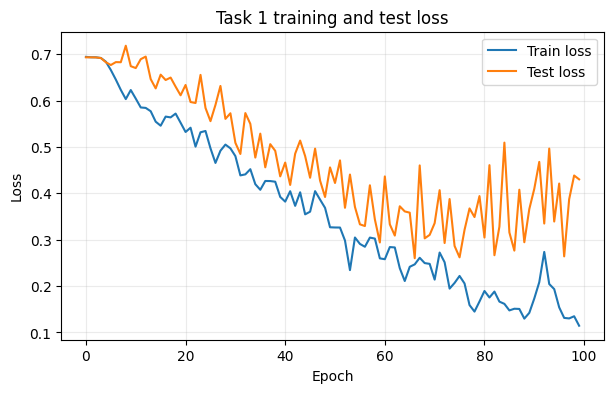

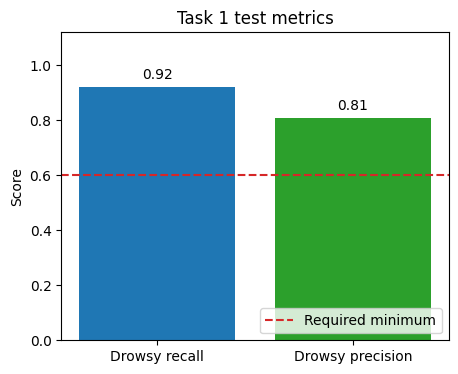

In [7]:
# This plot compares training and test loss over the full training run.
# A small gap near the end is expected because the model keeps fitting the training set.
plt.figure(figsize=(7, 4))
plt.plot(history["train_loss"], label="Train loss")
plt.plot(history["test_loss"], label="Test loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Task 1 training and test loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# The metric plot shows the two required drowsy-class metrics.
# The dashed line is the assignment threshold that both bars should pass.
plt.figure(figsize=(5, 4))
metric_names = ["Drowsy recall", "Drowsy precision"]
metric_values = [final_recall, final_precision]
plt.bar(metric_names, metric_values, color=["tab:blue", "tab:green"])
plt.axhline(0.6, linestyle="--", color="tab:red", label="Required minimum")
plt.ylim(0, 1.12)
plt.ylabel("Score")
plt.title("Task 1 test metrics")
plt.legend(loc="lower right")
for i, value in enumerate(metric_values):
    plt.text(i, value + 0.03, f"{value:.2f}", ha="center")
plt.show()

# Final numbers are printed so they are easy to report in the PDF/export.
print(f"Final test loss: {final_test_loss:.4f}")
print(f"Drowsy recall: {final_recall:.4f}")
print(f"Drowsy precision: {final_precision:.4f}")
print(
    "Confusion counts: "
    f"TP={final_counts['tp']}, FP={final_counts['fp']}, "
    f"FN={final_counts['fn']}, TN={final_counts['tn']}"
)


# Task 2

In [ ]:
class _BaseImageClassificationDataset(Dataset):
    """
    Base dataset for image classification datasets stored as:

        dataset_dir/
            class_to_id.json
            id_to_class.json
            train/
                000000.jpg
                ...
                labels.csv
                [metadata.csv]
            test/
                000000.jpg
                ...
                labels.csv
                [metadata.csv]
    """

    def __init__(
        self,
        dataset_dir,
        split="train",
        img_transform=None,
    ):
        super().__init__()
        self.dataset_dir = Path(dataset_dir)
        self.split = split
        self.img_transform = img_transform

        if self.split not in {"train", "test"}:
            raise ValueError(f"split must be 'train' or 'test', got: {self.split}")

        self.split_dir = self.dataset_dir / self.split
        self.labels_path = self.split_dir / "labels.csv"
        self.class_to_id_path = self.dataset_dir / "class_to_id.json"
        self.id_to_class_path = self.dataset_dir / "id_to_class.json"

        if not self.dataset_dir.exists():
            raise FileNotFoundError(f"Dataset directory not found: {self.dataset_dir}")
        if not self.split_dir.exists():
            raise FileNotFoundError(f"Split directory not found: {self.split_dir}")
        if not self.labels_path.exists():
            raise FileNotFoundError(f"labels.csv not found: {self.labels_path}")
        if not self.class_to_id_path.exists():
            raise FileNotFoundError(
                f"class_to_id.json not found: {self.class_to_id_path}"
            )
        if not self.id_to_class_path.exists():
            raise FileNotFoundError(
                f"id_to_class.json not found: {self.id_to_class_path}"
            )

        with open(self.class_to_id_path, "r") as fp:
            self.class_to_id = json.load(fp)

        with open(self.id_to_class_path, "r") as fp:
            self.id_to_class = json.load(fp)

        # Normalize keys for convenience
        self.id_to_class = {int(k): v for k, v in self.id_to_class.items()}
        self.num_classes = len(self.class_to_id)
        self.classes = [self.id_to_class[i] for i in range(self.num_classes)]

        self.labels = (
            pd.read_csv(self.labels_path, header=None).iloc[:, 0].astype(int).tolist()
        )

        self.img_paths = sorted(
            [
                p
                for p in self.split_dir.iterdir()
                if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png"}
            ],
            key=lambda p: p.name,
        )

        if len(self.img_paths) != len(self.labels):
            raise ValueError(
                f"Mismatch between number of images ({len(self.img_paths)}) and "
                f"labels ({len(self.labels)}) in split '{self.split}'."
            )

    def __len__(self):
        return len(self.labels)

    def _load_image(self, img_path):
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.img_transform is not None:
                img = self.img_transform(img)
            return img

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        image = self._load_image(img_path)
        label = self.labels[idx]

        return image, label


class BDDObjectClassificationDataset(_BaseImageClassificationDataset):
    """
    Dataset for the cropped-object classification dataset.

    Returns:
        image, label
    or:
        image, label, metadata   (if return_metadata=True)

    Notes:
        - img_transform defaults to None.
        - The user is responsible for resizing / tensor conversion.
    """

    pass


class PatchShuffle:
    def __init__(self, patch_size=8):
        self.p = patch_size

    def __call__(self, img):
        # Input: [C, H, W]
        c, h, w = img.shape
        p = self.p

        # 1. Unfold image into patches [C, H/p, W/p, p, p]
        patches = img.unfold(1, p, p).unfold(2, p, p)
        num_h = h // p
        num_w = w // p

        # 2. Reshape to [num_patches, C, p, p]
        patches = patches.contiguous().view(c, -1, p, p).permute(1, 0, 2, 3)

        # 3. Shuffle the patches along the first dimension
        idx = torch.randperm(patches.size(0))
        patches = patches[idx]

        # 4. Reshape back to original image dimensions
        # We need to rearrange from [num_h*num_w, C, p, p] back to [C, H, W]
        patches = patches.view(num_h, num_w, c, p, p).permute(2, 0, 3, 1, 4)
        shuffled_img = patches.contiguous().view(c, h, w)

        return shuffled_img

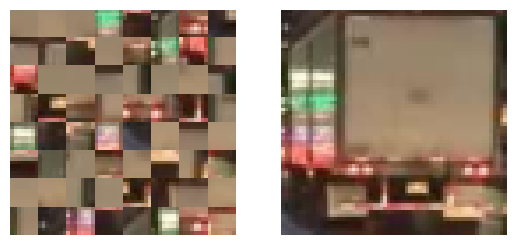

In [45]:
train_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="train",
    img_transform=None,  # Fill train image transforms
)

test_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=None,  # Fill test image transforms
)

### See how Patch Shuffle affects an image: CODE MEANT FOR ILLUSTRATION ###
from torchvision.transforms import Compose, ToTensor, Resize
from torchvision.transforms import functional as vf
import matplotlib.pyplot as plt

vis_dataset_noisy = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=Compose([Resize((64, 64)), ToTensor(), PatchShuffle(patch_size=8)]),
)
vis_dataset_clean = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=Compose([Resize((64, 64)), ToTensor()]),
)
fig, ax = plt.subplots(1, 2)
img_noisy, label = vis_dataset_noisy[16]
img_clean, label = vis_dataset_clean[16]
ax[0].imshow(vf.to_pil_image(img_noisy))
ax[1].imshow(vf.to_pil_image(img_clean))
for a in ax:
    a.set_xticks([])
    a.set_yticks([])
    a.set_frame_on(False)
### See how Patch Shuffle affects an image: CODE MEANT FOR ILLUSTRATION ###

## Task 3 

In [ ]:
# This utility class is aimed to help you a bit with the linear probe classifier.
# You can choose whether to implement it or not!


class LinearProbeClassifier(nn.Module):
    """
    Frozen pretrained backbone + trainable linear classification head.

    TODO:
    - load a pretrained backbone,
    - remove/replace its original classification head (if any),
    - freeze the backbone parameters,
    - add a new trainable linear head for the BDD classes.
    """

    def __init__(self, backbone_arch: str, num_classes: int):
        super().__init__()
        self.backbone = None  # Here you can use a function that creates the backbone model based on the backbone_arch string (take a look here: https://docs.pytorch.org/vision/main/models.html)

        # TODO: Sometimes the pretrained backbone may already have a classification head (e.g. ResNet's fc layer, ViT's heads layer). In this case you might need to replace it with an Identity layer to get the features before the head.
        # The Identity layer is simply a placeholder for the Identity function, which returns its input unchanged.

        # TODO: freeze all pretrained backbone parameters. Freezing a parameter means that it will not be updated during gradient updates.

        # TODO: define the trainable linear classification head
        self.linear_head = None

    def forward(self, x: torch.Tensor):
        # The backbone should be used as a feature extractor.

        # Then the features from the backbone are passed through the linear head to get the final logits for classification.
        pass